# PlanetScope Follow-Up for the Largest Fire Cluster

This notebook continues the workflow from `10_largest_fire_today_workflow copy.ipynb`.

## Libraries and datasets
1. `earthengine-api` lets us load and buffer the fire GeoJSON with Earth Engine.
2. `geemap` gives us an interactive map inside the notebook.
3. `planet` is the Planet SDK we use to search the catalog, create the order, and download the result.
4. `rasterio`, `numpy`, and `matplotlib` help us read the downloaded COG and display bands locally.

The input dataset is the largest-fire GeoJSON exported by the previous fire notebook and saved in `notebooks/output/`.
We buffer that geometry by 1000 meters, search the PlanetScope catalog for the most recent scene that overlaps it, and order an orthorectified Cloud Optimized GeoTIFF (COG) clipped to the buffered area.

![Placeholder: A buffered fire polygon overlaid on a recent PlanetScope scene footprint with a clipped COG preview.]()

## What you should understand
1. Why we buffer the fire boundary before searching and ordering imagery.
2. How Planet SDK search and order requests work together.
3. How to read a downloaded COG and display RGB and IRG views.
4. Why true NBR needs SWIR bands, which PlanetScope does not provide.


In [18]:
# Install the libraries used in this notebook.
# This cell is safe to rerun in Colab and in a local Jupyter environment.
!pip install -q --upgrade earthengine-api geemap planet rasterio numpy matplotlib python-dotenv


## Imports and helper functions

The helper functions below keep the notebook rerun-safe.
They also make it easier for beginners to follow what the code is doing step by step.


In [32]:
# Core standard-library tools.
import json
import os
from datetime import datetime, timedelta, timezone
from pathlib import Path

# Earth Engine lets us buffer the fire boundary in meters.
import ee

# geemap gives us a simple interactive map widget.
import geemap

# Planet SDK objects for authentication, search, and orders.
from planet import Auth, Planet, Session, data_filter
from planet.exceptions import InvalidAPIKey
from planet.order_request import build_request, clip_tool, file_format_tool, product
# python-dotenv loads key/value pairs from a local env file.
from dotenv import load_dotenv

# Local raster tools for reading the downloaded COG.
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# Use the same Earth Engine project pattern as the rest of the repo.
GEE_PROJECT = 'sdm-gee-project-02'

# Resolve the notebook's output folder no matter whether we start from the repo root
# or from inside the notebooks/ directory.
def resolve_output_dir() -> Path:
    """Return the existing output folder used by the notebooks."""
    candidates = [Path('notebooks/output'), Path('output')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return Path('notebooks/output')


# Pick the newest fire GeoJSON that was exported by the previous notebook.
def find_latest_fire_geojson(output_dir: Path) -> Path:
    """Return the most recently modified largest-fire GeoJSON file."""
    candidates = sorted(
        output_dir.glob('*largest_fire_cluster*.geojson'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            'Could not find a largest-fire GeoJSON in output/. Run the previous notebook first.'
        )
    return candidates[0]


# Stretch each image band to help with notebook display.
def stretch_minmax(arr: np.ndarray) -> np.ndarray:
    """Scale values to 0-1 using each band's minimum and maximum."""
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        return arr
    lo = np.min(valid)
    hi = np.max(valid)
    if hi == lo:
        return np.zeros_like(arr, dtype='float32')
    clipped = np.clip(arr, lo, hi)
    return (clipped - lo) / (hi - lo)


## Authentication

We authenticate to Earth Engine and Planet separately because they are different services.

For Planet, the notebook first looks for a `PL_API_KEY` environment variable.
If one is not available, it falls back to the SDK profile-based login flow.


In [20]:
# Connect to Earth Engine. If this fails, the notebook will ask you to authenticate.
try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)

# Load the Planet API key from the repo's env example file.
# This keeps the notebook tied to the workspace's shared auth setup.
env_example_path = Path('/Users/maples/GitHub/google_earth_engine_python_101/.env.example')
if env_example_path.exists():
    load_dotenv(env_example_path)

def connect_to_planet():
    """Try the env-file API key first, then fall back to the Planet CLI profile."""
    pl_api_key = os.environ.get('PL_API_KEY')

    if pl_api_key:
        # If the key from the env file is valid, this is the fastest path.
        try:
            client = Planet(Session(Auth.from_key(pl_api_key)))
            # Make a tiny authenticated call right away so we fail here, not later.
            list(client.data.search(['PSScene'], limit=1))
            print('Planet authenticated with PL_API_KEY from .env.example.')
            return client
        except InvalidAPIKey:
            print('The PL_API_KEY loaded from .env.example was rejected by Planet.')
            print('Please replace it with a valid Planet API key, or let the notebook use the Planet CLI profile instead.')
        except Exception:
            raise

    # The SDK profile login is a helpful fallback for users who already logged in with the Planet CLI.
    planet_auth = Auth.from_profile('planet-user', save_state_to_storage=False)
    if not planet_auth.is_initialized():
        planet_auth.user_login(allow_open_browser=True, allow_tty_prompt=True)

    client = Planet(Session(planet_auth))
    list(client.data.search(['PSScene'], limit=1))
    print('Planet authenticated with the planet-user profile.')
    return client

pl = connect_to_planet()
print('Earth Engine and Planet are ready.')


The PL_API_KEY loaded from .env.example was rejected by Planet.
Please replace it with a valid Planet API key, or let the notebook use the Planet CLI profile instead.
Opening browser to login.
Confirm the authorization code when prompted: JBFB-NDRR

Planet authenticated with the planet-user profile.
Earth Engine and Planet are ready.


## Load and buffer the fire geometry

The earlier fire notebook exported the largest cluster as GeoJSON.
Here we load that file, buffer it by 1000 meters, and save a new buffered GeoJSON so the Planet order uses the same area of interest every time we rerun the notebook.

Buffering matters because a fire boundary is usually a little too tight for imagery ordering.
Adding a buffer gives us context around the burn scar and helps ensure the scene includes the full fire edge and nearby surroundings.


In [33]:
# Find the most recent fire GeoJSON from the previous notebook.
output_dir = resolve_output_dir()
output_dir.mkdir(parents=True, exist_ok=True)
fire_geojson_path = find_latest_fire_geojson(output_dir)
print(f'Using fire GeoJSON: {fire_geojson_path}')

# Load the GeoJSON from disk.
with fire_geojson_path.open('r', encoding='utf-8') as f:
    fire_geojson = json.load(f)

# The previous notebook wrote a FeatureCollection with a single fire polygon.
fire_feature = fire_geojson['features'][0]
fire_geometry = fire_feature['geometry']

# Earth Engine buffers in meters, so we can safely add 1000 m around the fire boundary.
fire_aoi = ee.Geometry(fire_geometry)
buffered_aoi = fire_aoi.buffer(1000)

# Save the buffered AOI as GeoJSON so the Planet order can reuse the exact same area.
buffered_geojson = {
    'type': 'FeatureCollection',
    'features': [
        {
            'type': 'Feature',
            'geometry': buffered_aoi.getInfo(),
            'properties': {
                'source_geojson': fire_geojson_path.name,
                'buffer_m': 1000,
            },
        }
    ],
}

buffered_geojson_path = output_dir / 'largest_fire_cluster_buffered_1000m.geojson'
with buffered_geojson_path.open('w', encoding='utf-8') as f:
    json.dump(buffered_geojson, f, indent=2)

print(f'Saved buffered AOI: {buffered_geojson_path}')

# Create a map so we can inspect the buffered AOI before ordering imagery.
aoi_map = geemap.Map()
aoi_map.addLayer(buffered_aoi, {'color': 'red'}, 'Buffered fire AOI (1000 m)')
aoi_map.centerObject(buffered_aoi, 11)
aoi_map


Using fire GeoJSON: output/2026-05-21_largest_fire_cluster.geojson
Saved buffered AOI: output/largest_fire_cluster_buffered_1000m.geojson


Map(center=[52.44908224812429, 127.37841229900623], controls=(WidgetControl(options=['position', 'transparent_…

## Search for the most recent PlanetScope scene

Planet's Data API lets us search for scenes by location and time.
We ask for PlanetScope scenes that intersect the buffered fire AOI, then sort by acquisition time so the newest scene appears first.

We also ask for imagery the current account is allowed to download.
That keeps the search results realistic for students working with their own Planet credentials.


In [22]:
# Convert the buffered AOI into plain GeoJSON for the Planet search filter.
buffered_geom_geojson = buffered_aoi.getInfo()

# Keep the search window reasonably recent so we get the most current PlanetScope pass.
search_end = datetime.now(timezone.utc)
search_start = search_end - timedelta(days=90)

# Build a search filter that combines geometry, time, access permissions, and asset availability.
search_filter = data_filter.and_filter([
    data_filter.geometry_filter(geom=buffered_geom_geojson),
    data_filter.date_range_filter(
        field_name='acquired',
        gte=search_start,
        lte=search_end,
    ),
    data_filter.asset_filter(asset_types=['ortho_analytic_8b', 'ortho_analytic_4b']),
    data_filter.permission_filter(),
    data_filter.range_filter(field_name='cloud_cover', gte=0.0, lte=0.9),
])

# Search PlanetScope and sort by acquisition time, newest first.
search_results = list(pl.data.search(['PSScene'], search_filter=search_filter, sort='acquired desc', limit=10))

if not search_results:
    raise RuntimeError(
        'No PlanetScope scenes matched the buffered AOI. Try widening the date window or relaxing the cloud filter.'
    )

selected_scene = search_results[0]
selected_scene_id = selected_scene['id']
selected_scene_geom = selected_scene['geometry']
selected_scene_properties = selected_scene.get('properties', {})

print('Selected PlanetScope scene:')
print(f"  id: {selected_scene_id}")
print(f"  acquired: {selected_scene_properties.get('acquired')}")
print(f"  published: {selected_scene_properties.get('published')}")
print(f"  cloud_cover: {selected_scene_properties.get('cloud_cover')}")

# Show the fire AOI and the selected scene footprint together.
scene_map = geemap.Map()
scene_map.addLayer(buffered_aoi, {'color': 'red'}, 'Buffered fire AOI')
scene_map.addLayer(ee.Geometry(selected_scene_geom), {'color': 'yellow'}, 'Selected PlanetScope footprint')
scene_map.centerObject(buffered_aoi, 11)
scene_map


Selected PlanetScope scene:
  id: 20260527_023509_61_254d
  acquired: 2026-05-27T02:35:09.613053Z
  published: 2026-05-27T06:23:16Z
  cloud_cover: 0


Map(center=[52.44910064571562, 127.37841229960895], controls=(WidgetControl(options=['position', 'transparent_…

## Create the Planet order

This order asks Planet for an orthorectified PlanetScope scene, clips it to the buffered fire AOI, and delivers it as a Cloud Optimized GeoTIFF (COG).

We request the 8-band bundle first because it gives us the richest PlanetScope bands for RGB and infrared-style visualization.
A 4-band fallback is included so the workflow can still succeed if the 8-band bundle is not available for that scene.


In [23]:
# Build the ordered product request.
# The fallback bundle keeps the workflow useful even if an 8-band delivery is not available.
scene_product = product(
    item_ids=[selected_scene_id],
    item_type='PSScene',
    product_bundle='analytic_8b_udm2',
    fallback_bundle='analytic_udm2',
)

# Clip the imagery to the buffered fire AOI and convert the output to a COG.
clip = clip_tool(buffered_geom_geojson)
cog = file_format_tool(file_format='COG')

# Give the order a readable name so it is easy to identify later in the Planet dashboard.
order_name = f'largest_fire_followup_{selected_scene_id}'

# Build and submit the order request.
order_request = build_request(
    name=order_name,
    products=[scene_product],
    tools=[clip, cog],
)

order = pl.orders.create_order(order_request)
order_id = order['id'] if isinstance(order, dict) else getattr(order, 'id', None)
print('Order submitted:')
print(order_id)
print(order)

# Poll until Planet finishes preparing the order.
# This makes the download step safer to rerun because we only continue once the order is ready.
def wait_for_success(order_id: str, pause_seconds: int = 60, max_checks: int = 60):
    """Wait for a Planet order to reach success or partial success."""
    import time

    for check in range(max_checks):
        current = pl.orders.get_order(order_id)
        state = current['state'] if isinstance(current, dict) else getattr(current, 'state', None)
        print(f'Order check {check + 1}: {state}')
        if state in {'success', 'partial'}:
            return current
        if state in {'failed', 'cancelled'}:
            raise RuntimeError(f'Planet order ended in state: {state}')
        time.sleep(pause_seconds)

    raise TimeoutError('Planet order did not reach success within the polling window.')

# Wait for the order to finish before downloading.
final_order = wait_for_success(order_id)
print('Final order state:', final_order['state'] if isinstance(final_order, dict) else getattr(final_order, 'state', None))

# Download all files that belong to the order.
downloaded_paths = pl.orders.download_order(order_id)
print('Downloaded files:')
for path in downloaded_paths:
    print(path)

# Keep only the imagery COG and ignore sidecar metadata or mask files.
cog_candidates = [
    Path(path)
    for path in downloaded_paths
    if Path(path).suffix.lower() in {'.tif', '.tiff'} and 'udm' not in Path(path).name.lower()
]

if not cog_candidates:
    raise FileNotFoundError('The order finished, but no imagery COG was found among the downloaded files.')

cog_path = cog_candidates[0]
print('Imagery COG:', cog_path)


Order submitted:
2bc4707f-dfbc-4f9c-a019-c5200f412c8e
{'_links': {'_self': 'https://api.planet.com/compute/ops/orders/v2/2bc4707f-dfbc-4f9c-a019-c5200f412c8e'}, 'created_on': '2026-05-27T17:29:45.546158Z', 'error_hints': [], 'id': '2bc4707f-dfbc-4f9c-a019-c5200f412c8e', 'last_message': 'Preparing order', 'last_modified': '2026-05-27T17:29:45.546158Z', 'name': 'largest_fire_followup_20260527_023509_61_254d', 'products': [{'item_ids': ['20260527_023509_61_254d'], 'item_type': 'PSScene', 'product_bundle': 'analytic_8b_udm2'}], 'state': 'queued', 'tools': [{'clip': {'aoi': {'coordinates': [[[127.82027035173162, 52.51097197573089], [127.82024568102572, 52.51108969375261], [127.82024301043512, 52.51109560322496], [127.8202183395845, 52.51121332125214], [127.82008700066298, 52.511777566373084], [127.82008596650334, 52.5117797365912], [127.81997760549069, 52.51245178454128], [127.81978693213723, 52.512927291838814], [127.81979010883805, 52.512972867996666], [127.81975037961499, 52.513185908645

TimeoutError: Planet order did not reach success within the polling window.

## Display RGB and IRG

PlanetScope 8-band imagery uses these bands:
1. Coastal blue
2. Blue
3. Green I
4. Green
5. Yellow
6. Red
7. Red edge
8. Near infrared

For true color RGB on 8-band PlanetScope, the correct band order is `6, 4, 2`.
That means red comes from band 6, green from band 4, and blue from band 2.

That means we can build:
1. RGB with bands 6, 4, 2.
2. IRG with bands 8, 6, 4.

If the fallback 4-band bundle is used instead, the notebook automatically switches to the 4-band RGB and IRG band order.


## Resume order monitoring

If the polling window times out, do not create a new order right away.
Run the cell below to pick up the same `order_id` and continue checking the Planet order until it finishes.


In [26]:
# Reuse the existing order instead of submitting a duplicate one.
# This cell is meant to be rerun after a timeout.
def resume_order_monitoring(order_id: str, pause_seconds: int = 60, max_checks: int = 120):
    """Keep checking an existing Planet order until it reaches a final state."""
    import time

    print(f'Resuming monitoring for order: {order_id}')
    for check in range(max_checks):
        current = pl.orders.get_order(order_id)
        state = current['state'] if isinstance(current, dict) else getattr(current, 'state', None)
        print(f'Order check {check + 1}: {state}')
        if state in {'success', 'partial'}:
            return current
        if state in {'failed', 'cancelled'}:
            raise RuntimeError(f'Planet order ended in state: {state}')
        time.sleep(pause_seconds)

    raise TimeoutError('The order still has not reached a final state. Run this cell again later.')

# Run this after a timeout to continue waiting for the same order.
final_order = resume_order_monitoring(order_id)
print('Final order state:', final_order['state'] if isinstance(final_order, dict) else getattr(final_order, 'state', None))


Resuming monitoring for order: 2bc4707f-dfbc-4f9c-a019-c5200f412c8e
Order check 1: success
Final order state: success


## Download the finished order

Run this cell after the order reaches `success` or `partial`.
It checks the current state first so we do not try to download too early.


In [27]:
# Check the current state one more time before downloading.
latest_order = pl.orders.get_order(order_id)
latest_state = latest_order['state'] if isinstance(latest_order, dict) else getattr(latest_order, 'state', None)
print('Current order state:', latest_state)

if latest_state not in {'success', 'partial'}:
    raise RuntimeError('The order is not ready yet. Run the monitoring cell again later.')

# Download all files that belong to the order.
downloaded_paths = pl.orders.download_order(order_id)
print('Downloaded files:')
for path in downloaded_paths:
    print(path)

# Keep only the imagery COG and ignore sidecar metadata or mask files.
cog_candidates = [
    Path(path)
    for path in downloaded_paths
    if Path(path).suffix.lower() in {'.tif', '.tiff'} and 'udm' not in Path(path).name.lower()
]

if not cog_candidates:
    raise FileNotFoundError('The order finished, but no imagery COG was found among the downloaded files.')

cog_path = cog_candidates[0]
print('Imagery COG:', cog_path)


Current order state: success
Downloaded files:
2bc4707f-dfbc-4f9c-a019-c5200f412c8e/PSScene/20260527_023509_61_254d_metadata.json
2bc4707f-dfbc-4f9c-a019-c5200f412c8e/PSScene/20260527_023509_61_254d_3B_udm2_clip_file_format.tif
2bc4707f-dfbc-4f9c-a019-c5200f412c8e/PSScene/20260527_023509_61_254d_3B_AnalyticMS_8b_metadata_clip.xml
2bc4707f-dfbc-4f9c-a019-c5200f412c8e/PSScene/20260527_023509_61_254d_3B_AnalyticMS_8b_clip_file_format.tif
2bc4707f-dfbc-4f9c-a019-c5200f412c8e/manifest.json
Imagery COG: 2bc4707f-dfbc-4f9c-a019-c5200f412c8e/PSScene/20260527_023509_61_254d_3B_AnalyticMS_8b_clip_file_format.tif


COG bands: 8
CRS: None
Bounds: BoundingBox(left=359568.0, bottom=5802267.0, right=366015.0, top=5823372.0)


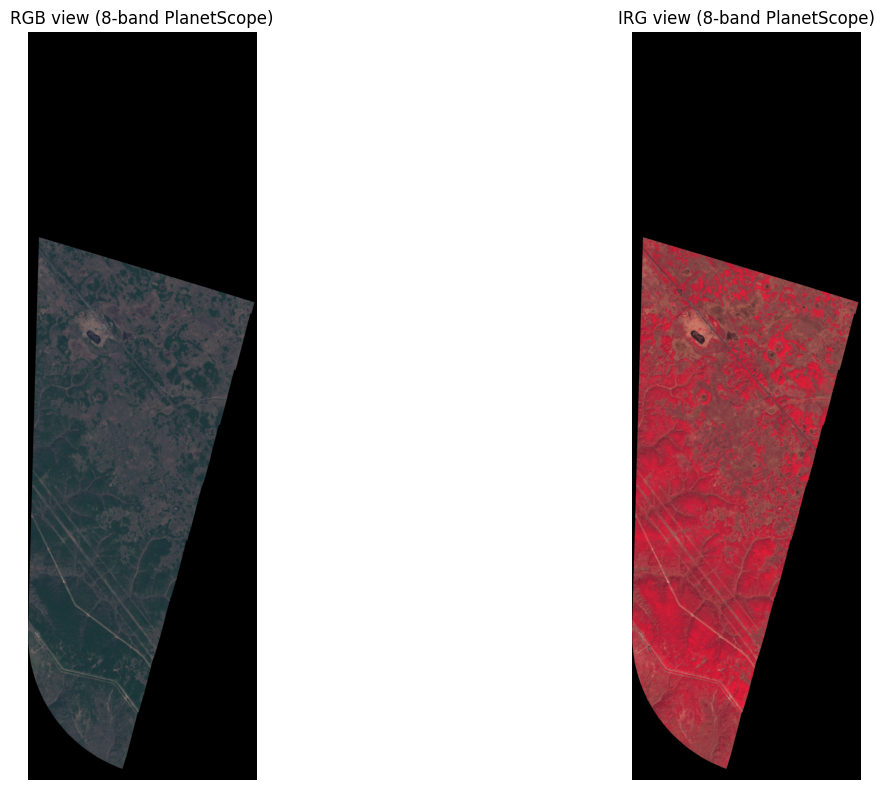

In [34]:
# Read the downloaded COG and decide which bands to use.
with rasterio.open(cog_path) as src:
    band_count = src.count
    image_crs = src.crs
    image_bounds = src.bounds
    print(f'COG bands: {band_count}')
    print(f'CRS: {image_crs}')
    print(f'Bounds: {image_bounds}')

    if band_count >= 8:
        rgb_bands = (6, 4, 2)
        irg_bands = (8, 6, 4)
        band_label = '8-band PlanetScope'
    elif band_count == 4:
        rgb_bands = (3, 2, 1)
        irg_bands = (4, 3, 2)
        band_label = '4-band PlanetScope'
    else:
        raise ValueError(f'Unexpected band count: {band_count}')

    # Read the bands we need and convert them into display-ready arrays.
    rgb = np.moveaxis(src.read(rgb_bands), 0, -1).astype('float32')
    irg = np.moveaxis(src.read(irg_bands), 0, -1).astype('float32')

# Stretch each channel independently so the image is easier to see.
rgb_display = np.dstack([stretch_minmax(rgb[:, :, i]) for i in range(3)])
irg_display = np.dstack([stretch_minmax(irg[:, :, i]) for i in range(3)])

# Show the two common visual interpretations side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(rgb_display)
axes[0].set_title(f'RGB view ({band_label})')
axes[0].axis('off')

axes[1].imshow(irg_display)
axes[1].set_title(f'IRG view ({band_label})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## NBR note

![Placeholder: NBR formula graphic showing `(NIR - SWIR) / (NIR + SWIR)` with a short note that PlanetScope does not provide SWIR bands.]()

True NBR needs a Short-Wave Infrared band.
PlanetScope imagery does not include SWIR, so we cannot compute a real NBR from this PlanetScope COG.

If you need actual NBR, reuse the same buffered AOI with a sensor that includes SWIR, such as Sentinel-2 or Landsat.
That is the right next step for burn severity analysis.


In [ ]:
# The notebook shows the NBR formula as a concept, but PlanetScope cannot support the calculation.
print('NBR reminder: (NIR - SWIR) / (NIR + SWIR)')
print('PlanetScope does not provide SWIR, so a true NBR cannot be computed from this image.')
print('Use Sentinel-2 or Landsat if you need a real burn index.')


## Wrap-up

You now have a buffered fire AOI, a recent PlanetScope order clipped to that area, and local RGB and IRG views of the downloaded COG.

The key teaching idea is that remote sensing workflows often move from a boundary, to a search, to an ordered image, and then to a visualization or index.
In this case, the final lesson is also a useful limitation: not every sensor can support every index.
